In [1]:
import pandas as pd
import numpy as np

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense

In [2]:
df = pd.read_csv("aqi_india_38cols_knn_final.csv")

# Clean column names
df.columns = df.columns.str.strip().str.lower()

# Fix city names
df['city'] = df['city'].str.strip().str.lower()

# Rename columns (adjust if needed)
df.rename(columns={
    'datetime': 'timestamp',
    'pm2_5_ugm3': 'pm2_5'
}, inplace=True)

# Keep required columns
df = df[['city', 'timestamp', 'pm2_5']].dropna()

print("Total cities:", df['city'].nunique())
df.head()

Total cities: 29


,city,timestamp,pm2_5
0,agartala,2022-08-05 00:00:00,14.8
1,agartala,2022-08-05 01:00:00,15.7
2,agartala,2022-08-05 02:00:00,16.3
3,agartala,2022-08-05 03:00:00,17.6
4,agartala,2022-08-05 04:00:00,18.2


In [3]:
def preprocess_city(df_city):
    df_city['timestamp'] = pd.to_datetime(df_city['timestamp'])
    df_city = df_city.sort_values('timestamp')
    
    df_city = df_city[['timestamp', 'pm2_5']]
    df_city = df_city.set_index('timestamp')
    
    df_city = df_city.resample('h').mean().ffill()
    
    return df_city

In [4]:
city_data = {}

for city in df['city'].unique():
    city_df = df[df['city'] == city].copy()
    
    if len(city_df) < 20:
        continue
    
    try:
        processed = preprocess_city(city_df)
        
        if len(processed) > 0:
            city_data[city] = processed
            
    except Exception as e:
        print("Skipping:", city, e)

print("Usable cities:", len(city_data))
list(city_data.keys())[:10]

Usable cities: 29


['agartala',
 'ahmedabad',
 'aizawl',
 'bengaluru',
 'bhopal',
 'bhubaneswar',
 'chandigarh',
 'chennai',
 'dehradun',
 'delhi']

In [5]:
available_cities = sorted(city_data.keys())

train_cities = available_cities[:20]
test_cities = available_cities[20:30]

print("Train:", train_cities)
print("Test:", test_cities)

Train: ['agartala', 'ahmedabad', 'aizawl', 'bengaluru', 'bhopal', 'bhubaneswar', 'chandigarh', 'chennai', 'dehradun', 'delhi', 'gangtok', 'gurugram', 'guwahati', 'hyderabad', 'imphal', 'itanagar', 'jaipur', 'kohima', 'kolkata', 'lucknow']
Test: ['mumbai', 'panaji', 'patna', 'raipur', 'ranchi', 'shillong', 'shimla', 'thiruvananthapuram', 'visakhapatnam']


In [6]:
all_data = np.concatenate([city_data[c].values for c in available_cities])

scaler = MinMaxScaler()
scaler.fit(all_data)

for city in available_cities:
    city_data[city] = scaler.transform(city_data[city])

C:\Users\Kushali Gupta\anaconda3\Lib\site-packages\sklearn\base.py:486: UserWarning: X has feature names, but MinMaxScaler was fitted without feature names
  warnings.warn(
C:\Users\Kushali Gupta\anaconda3\Lib\site-packages\sklearn\base.py:486: UserWarning: X has feature names, but MinMaxScaler was fitted without feature names
  warnings.warn(
C:\Users\Kushali Gupta\anaconda3\Lib\site-packages\sklearn\base.py:486: UserWarning: X has feature names, but MinMaxScaler was fitted without feature names
  warnings.warn(
C:\Users\Kushali Gupta\anaconda3\Lib\site-packages\sklearn\base.py:486: UserWarning: X has feature names, but MinMaxScaler was fitted without feature names
  warnings.warn(
C:\Users\Kushali Gupta\anaconda3\Lib\site-packages\sklearn\base.py:486: UserWarning: X has feature names, but MinMaxScaler was fitted without feature names
  warnings.warn(
C:\Users\Kushali Gupta\anaconda3\Lib\site-packages\sklearn\base.py:486: UserWarning: X has feature names, but MinMaxScaler was fitted w

In [7]:
def create_sequences(data, seq_length=24):
    X, y = [], []
    
    for i in range(len(data) - seq_length):
        X.append(data[i:i+seq_length])
        y.append(data[i+seq_length][0])
    
    return np.array(X), np.array(y)

In [8]:
X_train, y_train = [], []
X_test, y_test = [], []

for city in train_cities:
    X, y = create_sequences(city_data[city])
    X_train.append(X)
    y_train.append(y)

for city in test_cities:
    X, y = create_sequences(city_data[city])
    X_test.append(X)
    y_test.append(y)

X_train = np.vstack(X_train)
y_train = np.hstack(y_train)

X_test = np.vstack(X_test)
y_test = np.hstack(y_test)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

Train shape: (580320, 24, 1)
Test shape: (261144, 24, 1)


In [9]:
threshold = np.percentile(y_train, 95)

weights = np.ones_like(y_train)
weights[y_train > threshold] = 3.0

In [10]:
def build_model():
    model = Sequential()
    model.add(LSTM(64, input_shape=(24, 1)))
    model.add(Dense(1))
    
    model.compile(optimizer='adam', loss='mse')
    return model

model = build_model()
model.summary()

C:\Users\Kushali Gupta\anaconda3\Lib\site-packages\keras\src\layers\rnn\rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 64)             │        16,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 16,961 (66.25 KB)

 Trainable params: 16,961 (66.25 KB)

 Non-trainable params: 0 (0.00 B)

In [11]:
model.fit(
    X_train, y_train,
    sample_weight=weights,
    epochs=10,
    batch_size=32,
    verbose=1
)

Epoch 1/10
18135/18135 ━━━━━━━━━━━━━━━━━━━━ 183s 10ms/step - loss: 0.0018
Epoch 2/10
18135/18135 ━━━━━━━━━━━━━━━━━━━━ 145s 7ms/step - loss: 8.2860e-04
Epoch 3/10
18135/18135 ━━━━━━━━━━━━━━━━━━━━ 143s 7ms/step - loss: 7.9179e-04
Epoch 4/10
18135/18135 ━━━━━━━━━━━━━━━━━━━━ 146s 7ms/step - loss: 7.8975e-04
Epoch 5/10
18135/18135 ━━━━━━━━━━━━━━━━━━━━ 141s 7ms/step - loss: 7.5780e-04
Epoch 6/10
18135/18135 ━━━━━━━━━━━━━━━━━━━━ 125s 7ms/step - loss: 7.6790e-04
Epoch 7/10
18135/18135 ━━━━━━━━━━━━━━━━━━━━ 139s 7ms/step - loss: 7.5785e-04
Epoch 8/10
18135/18135 ━━━━━━━━━━━━━━━━━━━━ 115s 6ms/step - loss: 7.6117e-04
Epoch 9/10
18135/18135 ━━━━━━━━━━━━━━━━━━━━ 141s 6ms/step - loss: 7.4289e-04
Epoch 10/10
18135/18135 ━━━━━━━━━━━━━━━━━━━━ 116s 6ms/step - loss: 7.3094e-04


In [12]:
baseline_model = build_model()

baseline_model.fit(
    X_train, y_train,
    epochs=10,
    batch_size=32,
    verbose=1
)


Epoch 1/10
18135/18135 ━━━━━━━━━━━━━━━━━━━━ 123s 7ms/step - loss: 0.0010
Epoch 2/10
18135/18135 ━━━━━━━━━━━━━━━━━━━━ 118s 7ms/step - loss: 5.0269e-04
Epoch 3/10
18135/18135 ━━━━━━━━━━━━━━━━━━━━ 119s 7ms/step - loss: 4.9040e-04
Epoch 4/10
18135/18135 ━━━━━━━━━━━━━━━━━━━━ 125s 7ms/step - loss: 4.8289e-04
Epoch 5/10
18135/18135 ━━━━━━━━━━━━━━━━━━━━ 137s 7ms/step - loss: 4.7490e-04
Epoch 6/10
18135/18135 ━━━━━━━━━━━━━━━━━━━━ 123s 7ms/step - loss: 4.6906e-04
Epoch 7/10
18135/18135 ━━━━━━━━━━━━━━━━━━━━ 141s 7ms/step - loss: 4.6315e-04
Epoch 8/10
18135/18135 ━━━━━━━━━━━━━━━━━━━━ 141s 7ms/step - loss: 4.6272e-04
Epoch 9/10
18135/18135 ━━━━━━━━━━━━━━━━━━━━ 144s 7ms/step - loss: 4.5623e-04
Epoch 10/10
18135/18135 ━━━━━━━━━━━━━━━━━━━━ 139s 7ms/step - loss: 4.5734e-04


In [13]:
y_pred = model.predict(X_test)

y_pred = scaler.inverse_transform(y_pred)
y_test_actual = scaler.inverse_transform(y_test.reshape(-1, 1))

8161/8161 ━━━━━━━━━━━━━━━━━━━━ 30s 4ms/step


In [14]:
y_pred_base = baseline_model.predict(X_test)

y_pred_base = scaler.inverse_transform(y_pred_base)

8161/8161 ━━━━━━━━━━━━━━━━━━━━ 30s 4ms/step


In [27]:
from sklearn.metrics import r2_score
rmse = np.sqrt(mean_squared_error(y_test_actual, y_pred))
mae = mean_absolute_error(y_test_actual, y_pred)
r2 = r2_score(y_test_actual, y_pred)

print("Cross-City RMSE:", rmse)
print("Cross-City MAE:", mae)
print("R2:", r2)

Cross-City RMSE: 3.5365696953559866
Cross-City MAE: 1.94146450068332
R2: 0.9839843982219774


In [17]:
rmse_base = np.sqrt(mean_squared_error(y_test_actual, y_pred_base))
mae_base = mean_absolute_error(y_test_actual, y_pred_base)

print("Baseline RMSE:", rmse_base)
print("Baseline MAE:", mae_base)

Baseline RMSE: 3.4302604928506386
Baseline MAE: 1.7904715324267306


In [18]:
threshold_test = np.percentile(y_test_actual, 95)

spike_idx = y_test_actual.flatten() > threshold_test
non_spike_idx = ~spike_idx

rmse_spike = np.sqrt(mean_squared_error(
    y_test_actual[spike_idx], y_pred[spike_idx]
))

rmse_non_spike = np.sqrt(mean_squared_error(
    y_test_actual[non_spike_idx], y_pred[non_spike_idx]
))

print("Spike RMSE:", rmse_spike)
print("Non-Spike RMSE:", rmse_non_spike)

Spike RMSE: 8.286137774833968
Non-Spike RMSE: 3.094283499015861


In [19]:
threshold_90 = np.percentile(y_test_actual, 90)

spike90_idx = y_test_actual.flatten() > threshold_90

# Spike-aware model
rmse_spike90 = np.sqrt(mean_squared_error(
    y_test_actual[spike90_idx],
    y_pred[spike90_idx]
))

# Baseline model
rmse_spike90_base = np.sqrt(mean_squared_error(
    y_test_actual[spike90_idx],
    y_pred_base[spike90_idx]
))

print("=== Spike@90 Results ===")
print("Baseline Spike@90 RMSE:", rmse_spike90_base)
print("Spike-Aware Spike@90 RMSE:", rmse_spike90)

=== Spike@90 Results ===
Baseline Spike@90 RMSE: 7.116213318148096
Spike-Aware Spike@90 RMSE: 7.242036023330398


In [21]:
same_city_results = []

for city in test_cities:
    data = city_data[city]
    
    X, y = create_sequences(data)
    split = int(0.8 * len(X))
    
    X_train_c, X_test_c = X[:split], X[split:]
    y_train_c, y_test_c = y[:split], y[split:]
    
    threshold_c = np.percentile(y_train_c, 95)
    weights_c = np.ones_like(y_train_c)
    weights_c[y_train_c > threshold_c] = 3.0
    
    model_c = build_model()
    
    model_c.fit(X_train_c, y_train_c,
                sample_weight=weights_c,
                epochs=5,
                batch_size=32,
                verbose=0)
    
    y_pred_c = model_c.predict(X_test_c)
    
    y_pred_c = scaler.inverse_transform(y_pred_c)
    y_test_c = scaler.inverse_transform(y_test_c.reshape(-1,1))
    
    rmse_c = np.sqrt(mean_squared_error(y_test_c, y_pred_c))
    
    same_city_results.append((city, rmse_c))

same_df = pd.DataFrame(same_city_results, columns=["City", "SameCity_RMSE"])
print(same_df)

C:\Users\Kushali Gupta\anaconda3\Lib\site-packages\keras\src\layers\rnn\rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


182/182 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step


C:\Users\Kushali Gupta\anaconda3\Lib\site-packages\keras\src\layers\rnn\rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


182/182 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step


C:\Users\Kushali Gupta\anaconda3\Lib\site-packages\keras\src\layers\rnn\rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


...

182/182 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step


C:\Users\Kushali Gupta\anaconda3\Lib\site-packages\keras\src\layers\rnn\rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


182/182 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step


C:\Users\Kushali Gupta\anaconda3\Lib\site-packages\keras\src\layers\rnn\rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


182/182 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step
                 City  SameCity_RMSE
0              mumbai       3.049354
1              panaji       1.969930
2               patna       4.142527
3              raipur       4.247164
4              ranchi       3.441920
5            shillong       2.313995
6              shimla       3.534945
7  thiruvananthapuram       0.941163
8       visakhapatnam       2.537333


In [22]:
threshold_test = np.percentile(y_test_actual, 95)

spike_idx = y_test_actual.flatten() > threshold_test

rmse_spike_base = np.sqrt(mean_squared_error(
    y_test_actual[spike_idx],
    y_pred_base[spike_idx]
))

print("Baseline Spike RMSE:", rmse_spike_base)

Baseline Spike RMSE: 8.17730727832925


In [23]:
print("===== FINAL COMPARISON =====")

print("\n--- Overall ---")
print("Baseline RMSE:", rmse_base)
print("Spike-Aware RMSE:", rmse)

print("\n--- Spike ---")
print("Baseline Spike RMSE:", rmse_spike_base)
print("Spike-Aware Spike RMSE:", rmse_spike)

# % improvement
improve_overall = (rmse_base - rmse) / rmse_base * 100
improve_spike = (rmse_spike_base - rmse_spike) / rmse_spike_base * 100

print("\nImprovement Overall (%):", improve_overall)
print("Improvement Spike (%):", improve_spike)

===== FINAL COMPARISON =====

--- Overall ---
Baseline RMSE: 3.4302604928506386
Spike-Aware RMSE: 3.5365696953559866

--- Spike ---
Baseline Spike RMSE: 8.17730727832925
Spike-Aware Spike RMSE: 8.286137774833968

Improvement Overall (%): -3.099158292115659
Improvement Spike (%): -1.3308842727865948


In [30]:
cross_city_results = []

start = 0

for city in test_cities:
    data = city_data[city]
    X, y = create_sequences(data)
    
    length = len(y)
    
    # Extract predictions for THIS city
    y_pred_city = y_pred[start:start+length]
    y_true_city = y_test_actual[start:start+length]
    
    rmse_city = np.sqrt(mean_squared_error(y_true_city, y_pred_city))
    
    cross_city_results.append(rmse_city)
    
    start += length

same_df["CrossCity_RMSE"] = cross_city_results
same_df["Gap"] = same_df["CrossCity_RMSE"] - same_df["SameCity_RMSE"]
same_df["Gap"] = same_df["CrossCity_RMSE"] - same_df["SameCity_RMSE"]

print(same_df)

print("Avg Same-City RMSE:", same_df["SameCity_RMSE"].mean())
print("Cross-City RMSE:", rmse)

                 City  SameCity_RMSE  CrossCity_RMSE       Gap
0              mumbai       3.049354        4.369614  1.320260
1              panaji       1.969930        1.918594 -0.051337
2               patna       4.142527        4.447245  0.304718
3              raipur       4.247164        5.096570  0.849406
4              ranchi       3.441920        3.477667  0.035746
5            shillong       2.313995        2.357011  0.043017
6              shimla       3.534945        2.811817 -0.723129
7  thiruvananthapuram       0.941163        1.472178  0.531015
8       visakhapatnam       2.537333        4.039194  1.501861
Avg Same-City RMSE: 2.9087035782250896
Cross-City RMSE: 3.5365696953559866


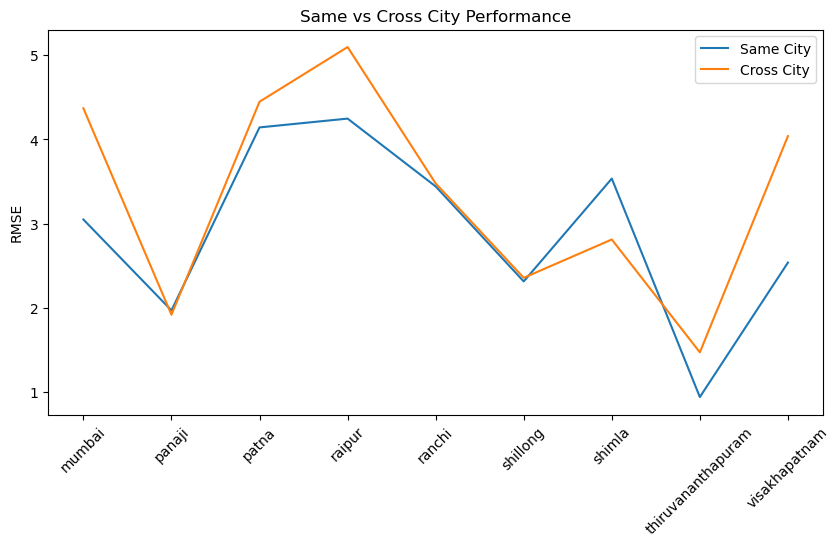

In [31]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10,5))

plt.plot(same_df["City"], same_df["SameCity_RMSE"], label="Same City")
plt.plot(same_df["City"], same_df["CrossCity_RMSE"], label="Cross City")

plt.xticks(rotation=45)
plt.ylabel("RMSE")
plt.title("Same vs Cross City Performance")
plt.legend()

plt.show()

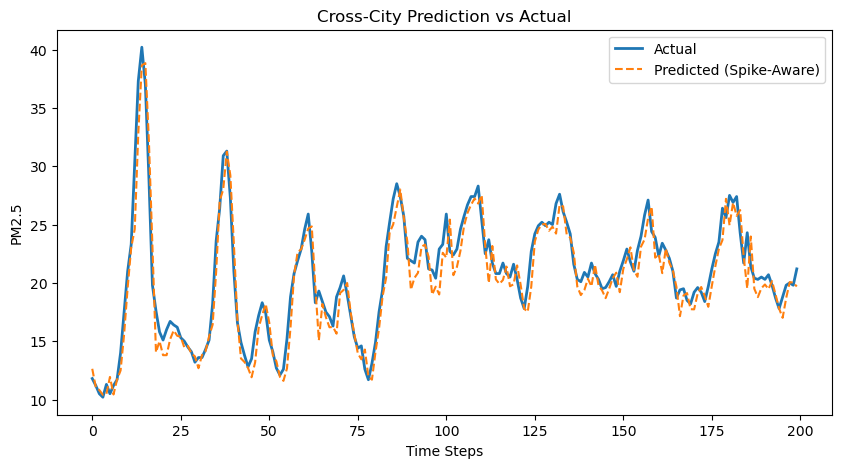

In [33]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

plt.plot(y_test_actual[:200], label='Actual', linewidth=2)
plt.plot(y_pred[:200], label='Predicted (Spike-Aware)', linestyle='--')

plt.title("Cross-City Prediction vs Actual")
plt.xlabel("Time Steps")
plt.ylabel("PM2.5")
plt.legend()

plt.show()

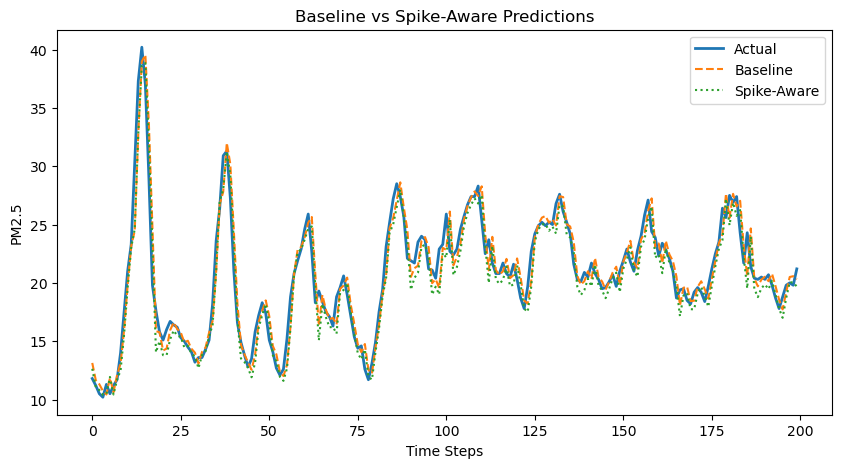

In [34]:
plt.figure(figsize=(10,5))

plt.plot(y_test_actual[:200], label='Actual', linewidth=2)
plt.plot(y_pred_base[:200], label='Baseline', linestyle='--')
plt.plot(y_pred[:200], label='Spike-Aware', linestyle=':')

plt.title("Baseline vs Spike-Aware Predictions")
plt.xlabel("Time Steps")
plt.ylabel("PM2.5")
plt.legend()

plt.show()

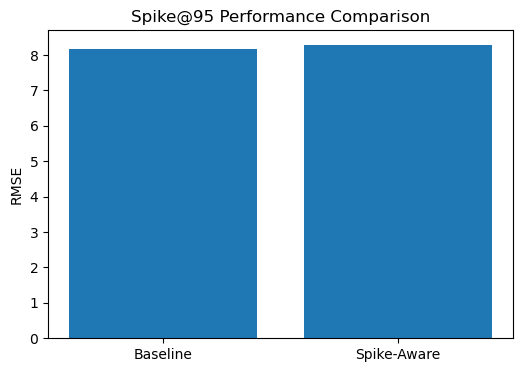

In [36]:
labels = ['Baseline', 'Spike-Aware']
values = [rmse_spike_base, rmse_spike]

plt.figure(figsize=(6,4))
plt.bar(labels, values)

plt.title("Spike@95 Performance Comparison")
plt.ylabel("RMSE")

plt.show()

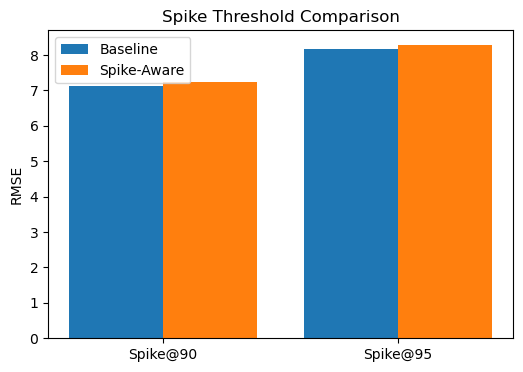

In [37]:
labels = ['Spike@90', 'Spike@95']

baseline_vals = [rmse_spike90_base, rmse_spike_base]
spike_vals = [rmse_spike90, rmse_spike]

x = range(len(labels))

plt.figure(figsize=(6,4))
plt.bar([i-0.2 for i in x], baseline_vals, width=0.4, label='Baseline')
plt.bar([i+0.2 for i in x], spike_vals, width=0.4, label='Spike-Aware')

plt.xticks(x, labels)
plt.ylabel("RMSE")
plt.title("Spike Threshold Comparison")
plt.legend()

plt.show()